# Phase 3. Explore public realm lingering potential

## 3.1 Immediate family public realm (400m)

These are the "I leave school and drift somewhere pleasant" variables.

- small_parks_400m
- playgrounds_400m
- gardens_400m

create a family_public_realm_score from these variables

In [ ]:
# Importing OSMnx, a Python library that enables the download, analysis, 
# and visualisation of geospatial data and street networks from 
# OpenStreetMap directly within Python.

import osmnx as ox

print(ox.__version__)

2.1.0


In [2]:
porto = ox.geocode_to_gdf("Porto, Portugal")

In [4]:
playgrounds = ox.features_from_polygon(
    porto.geometry.iloc[0],
    tags={"leisure": "playground"}
)

In [5]:
parks = ox.features_from_polygon(
    porto.geometry.iloc[0],
    tags={"leisure": ["park", "garden"]}
)

In [6]:
print(len(playgrounds))
print(len(parks))

playgrounds.head()
parks.head()

102
6852


geometry leisure  \
element id                                              
node    2377889036  POINT (-8.60267 41.14869)  garden   
        4466678185  POINT (-8.65822 41.16039)  garden   
        4643311478  POINT (-8.68839 41.16672)    park   
        4747717435  POINT (-8.64279 41.15273)  garden   
        4747717439  POINT (-8.64276 41.15292)  garden   

                                                name addr:city addr:street  \
element id                                                                   
node    2377889036                               NaN       NaN         NaN   
        4466678185                  Bosque das Faias       NaN         NaN   
        4643311478  Jardins da Avenida de Montevideu       NaN         NaN   
        4747717435              Núcleo das Palmeiras       NaN         NaN   
        4747717439             Clareira dos Plátanos       NaN         NaN   

                   alt_name contact:website internet_access official_name  \
element id                                                                  
node    2377889036      NaN             NaN             NaN           NaN   
        4466678185      NaN             NaN             NaN           NaN   
        4643311478      NaN             NaN             NaN           NaN   
        4747717435      NaN             NaN             NaN           NaN   
        4747717439      NaN             NaN             NaN           NaN   

                   opening_hours  ... note opening_date owner:website line  \
element id                        ...                                        
node    2377889036           NaN  ...  NaN          NaN           NaN  NaN   
        4466678185           NaN  ...  NaN          NaN           NaN  NaN   
        4643311478           NaN  ...  NaN          NaN           NaN  NaN   
        4747717435           NaN  ...  NaN          NaN           NaN  NaN   
        4747717439           NaN  ...  NaN          NaN           NaN  NaN   

                   contact:facebook contact:instagram contact:mobile  \
element id                                                             
node    2377889036              NaN               NaN            NaN   
        4466678185              NaN               NaN            NaN   
        4643311478              NaN               NaN            NaN   
        4747717435              NaN               NaN            NaN   
        4747717439              NaN               NaN            NaN   

                   contact:phone ownership reservation  
element id                                              
node    2377889036           NaN       NaN         NaN  
        4466678185           NaN       NaN         NaN  
        4643311478           NaN       NaN         NaN  
        4747717435           NaN       NaN         NaN  
        4747717439           NaN       NaN         NaN  

[5 rows x 84 columns]

In [7]:
# OSM data arrives in WGS84, I need to convert to Portuguese metric coordinates:
playgrounds = playgrounds.to_crs(3763)
parks = parks.to_crs(3763)

<Axes: >

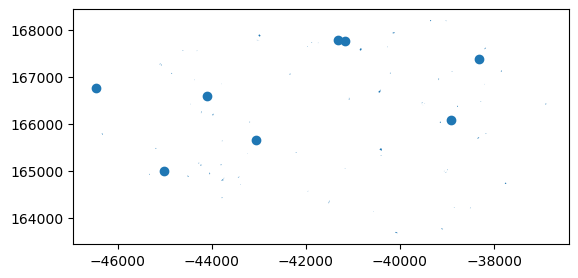

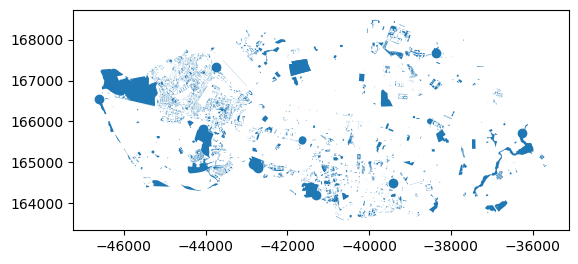

In [8]:
playgrounds.plot()
parks.plot()

In [9]:
# Exporting to QGIS:

playgrounds.to_file(
    "../Data/Processed/playgrounds_osm.gpkg",
    driver="GPKG"
)

parks.to_file(
    "../Data/Processed/parks_osm.gpkg",
    driver="GPKG"
)

In [10]:
parks["area_m2"] = parks.geometry.area

small_parks = parks[parks["area_m2"] < 20000]
large_parks = parks[parks["area_m2"] >= 20000]

In [11]:
from pathlib import Path
import pandas as pd

# Folder and output file
processed_dir = Path("../Data/Processed")
processed_dir.mkdir(parents=True, exist_ok=True)

amenities_path = processed_dir / "urban_amenities.gpkg"

# Rebuild this GeoPackage from scratch each time this notebook runs.
# This does NOT affect bgri_master.gpkg.
if amenities_path.exists():
    amenities_path.unlink()


def clean_for_qgis(gdf):
    """
    Keep only useful OSM columns and make the layer safe to export to GeoPackage.
    OSM often contains many irregular columns, so this avoids export problems
    and keeps QGIS tidy.
    """
    gdf = gdf.copy()
    gdf = gdf[gdf.geometry.notna()].copy()

    # Make invalid geometries valid where possible
    try:
        gdf["geometry"] = gdf.geometry.make_valid()
    except Exception:
        pass

    # Preserve OSM index values such as element type / osmid
    gdf = gdf.reset_index()

    # Add geometry type for visual inspection
    gdf["geometry_type"] = gdf.geometry.geom_type

    # Add area, useful for parks/gardens
    if "area_m2" not in gdf.columns:
        gdf["area_m2"] = gdf.geometry.area

    useful_cols = [
        "element_type",
        "element",
        "osmid",
        "id",
        "name",
        "leisure",
        "amenity",
        "shop",
        "tourism",
        "operator",
        "addr:street",
        "addr:housenumber",
        "geometry_type",
        "area_m2",
    ]

    existing_cols = [c for c in useful_cols if c in gdf.columns]

    out = gdf[existing_cols + ["geometry"]].copy()

    # Convert lists/dicts into strings so GeoPackage export does not complain
    for col in out.columns:
        if col != "geometry":
            out[col] = out[col].apply(
                lambda x: "; ".join(map(str, x)) if isinstance(x, (list, tuple, set))
                else str(x) if isinstance(x, dict)
                else x
            )

    return out


def write_layer(gdf, layer_name):
    """
    Write a GeoDataFrame as one layer inside urban_amenities.gpkg.
    """
    if gdf.empty:
        print(f"Skipped {layer_name}: empty layer")
        return

    gdf.to_file(
        amenities_path,
        layer=layer_name,
        driver="GPKG"
    )

    print(
        f"Wrote {layer_name}: {len(gdf)} features | "
        f"{gdf.geometry.geom_type.value_counts().to_dict()}"
    )


def make_buffer_layer(gdf, distance_m):
    """
    Create visual buffer polygons around the amenity geometries.
    These are for QGIS inspection, not yet the final analytical variables.
    """
    buffered = gdf.copy()
    buffered["buffer_m"] = distance_m
    buffered["geometry"] = buffered.geometry.buffer(distance_m)
    return buffered


# Clean layers for QGIS
porto_boundary_qgis = clean_for_qgis(porto.to_crs(3763))
playgrounds_qgis = clean_for_qgis(playgrounds)
parks_qgis = clean_for_qgis(parks)
small_parks_qgis = clean_for_qgis(small_parks)
large_parks_qgis = clean_for_qgis(large_parks)

# Create visual buffer layers
playgrounds_400m_buffer = make_buffer_layer(playgrounds_qgis, 400)
small_parks_400m_buffer = make_buffer_layer(small_parks_qgis, 400)
large_parks_800m_buffer = make_buffer_layer(large_parks_qgis, 800)

# Export all layers into one GeoPackage
write_layer(porto_boundary_qgis, "porto_boundary")
write_layer(playgrounds_qgis, "playgrounds_osm")
write_layer(parks_qgis, "parks_gardens_osm")
write_layer(small_parks_qgis, "small_parks_gardens")
write_layer(large_parks_qgis, "large_parks_gardens")

write_layer(playgrounds_400m_buffer, "playgrounds_400m_buffer")
write_layer(small_parks_400m_buffer, "small_parks_400m_buffer")
write_layer(large_parks_800m_buffer, "large_parks_800m_buffer")

print(f"\nExport complete: {amenities_path}")

Wrote porto_boundary: 1 features | {'Polygon': 1}
Wrote playgrounds_osm: 102 features | {'Polygon': 94, 'Point': 8}
Wrote parks_gardens_osm: 6852 features | {'Polygon': 6830, 'Point': 15, 'MultiPolygon': 7}
Wrote small_parks_gardens: 6834 features | {'Polygon': 6814, 'Point': 15, 'MultiPolygon': 5}
Wrote large_parks_gardens: 18 features | {'Polygon': 16, 'MultiPolygon': 2}
Wrote playgrounds_400m_buffer: 102 features | {'Polygon': 102}
Wrote small_parks_400m_buffer: 6834 features | {'Polygon': 6834}
Wrote large_parks_800m_buffer: 18 features | {'Polygon': 18}

Export complete: ..\Data\Processed\urban_amenities.gpkg


## 3.2 Destination leisure area (800m)

This captures neighbourhood attractiveness and weekend routines.

large_parks_800m

## 3.3 Accessibility (800m)

For this customer profile, parking and metro matters more than bus. 

Metro variable: distance to nearest metro.

Finding reliable parking datasets is often surprisingly hard.

Potential proxies:

surface parking lots within 400m
average street width
residential density inverse
parking garages within 600m

I need to think the best way to see this, because although it is hard data to find, it is potentially the make-or-break factor in a city where most of the upper middle class relies mainly on the car to circulate (except for foreign citizens).

## 3.4 Cultural and intellectual amenities (600m)

Variables:
- libraries_600m
- bookshops_600m
- cultural_venues_600m
- coworking_spaces_600m (target customer includes freelancers and remote workers)

These variables measure neighbourhoods where lingering, reading and cultural consumption already exist.